# Regressão 01 - tarefa 02 - transformações em X e Y

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

%matplotlib inline

tips = sns.load_dataset("tips")
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips['tip_pct'] = tips['tip'] / tips['net_bill']

tips.head()

,total_bill,tip,sex,smoker,day,time,size,net_bill,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,15.98,0.063204
1,10.34,1.66,Male,No,Sun,Dinner,3,8.68,0.191244
2,21.01,3.50,Male,No,Sun,Dinner,3,17.51,0.199886
3,23.68,3.31,Male,No,Sun,Dinner,2,20.37,0.162494
4,24.59,3.61,Female,No,Sun,Dinner,4,20.98,0.172069


### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

In [2]:
reg_base = smf.ols('tip_pct ~ net_bill', data=tips).fit()
reg_base.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     24.31
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.52e-06
Time:                        17:42:36   Log-Likelihood:                 108.00
No. Observations:                 244   AIC:                            -212.0
Df Residuals:                     242   BIC:                            -205.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3053      0.023     13.166      0.000       0.260       0.351
net_bill      -0.0061      0.001     -4.931      0.000      -0.009      -0.004
==============================================================================
Omnibus:                      468.674   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           234437.604
Skew:                          11.104   Prob(JB):                         0.00
Kurtosis:                     153.221   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [3]:
R2_base = reg_base.rsquared
R2_base

np.float64(0.09129084920662978)

### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

In [4]:
tips['log_net_bill'] = np.log(tips['net_bill'])

reg_logx = smf.ols('tip_pct ~ log_net_bill', data=tips).fit()
reg_logx.summary()

R2_logx = reg_logx.rsquared
R2_logx

np.float64(0.20172884237605493)

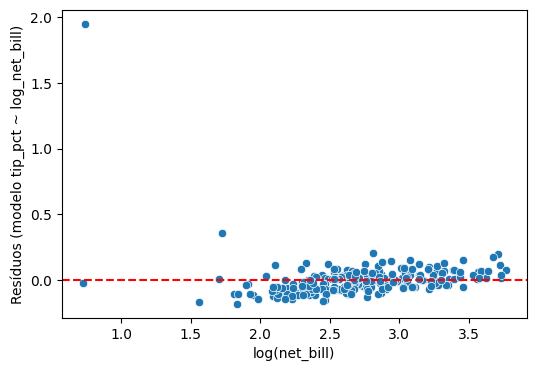

In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=tips['log_net_bill'], y=reg_logx.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('log(net_bill)')
plt.ylabel('Resíduos (modelo tip_pct ~ log_net_bill)')
plt.show()

###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

In [6]:
reg_poly = smf.ols('tip_pct ~ net_bill + np.power(net_bill, 2)', data=tips).fit()
reg_poly.summary()

R2_poly = reg_poly.rsquared
R2_poly

np.float64(0.15760784734296152)

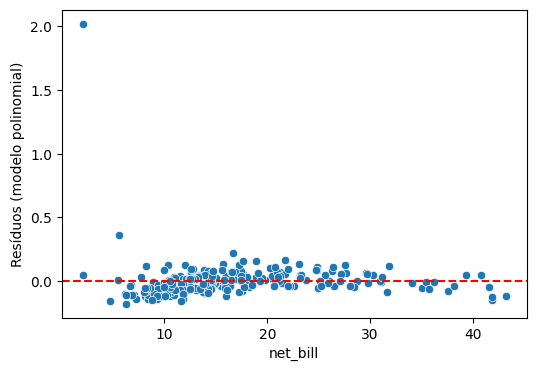

In [7]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=tips['net_bill'], y=reg_poly.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Resíduos (modelo polinomial)')
plt.show()

###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

In [8]:
tips['log_tip_pct'] = np.log(tips['tip_pct'])

reg_logy = smf.ols('log_tip_pct ~ net_bill', data=tips).fit()
reg_logy.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_tip_pct   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     74.48
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           8.27e-16
Time:                        17:43:41   Log-Likelihood:                -106.00
No. Observations:                 244   AIC:                             216.0
Df Residuals:                     242   BIC:                             223.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2749      0.056    -22.872      0.000      -1.385      -1.165
net_bill      -0.0259      0.003     -8.630      0.000      -0.032      -0.020
==============================================================================
Omnibus:                       49.929   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.392
Skew:                           0.664   Prob(JB):                     7.78e-57
Kurtosis:                       7.864   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
log_pred = reg_logy.fittedvalues

In [10]:
tip_pct_pred = np.exp(log_pred)

In [11]:
y_obs = tips['tip_pct']
y_pred = tip_pct_pred

SSE = ((y_obs - y_pred)**2).sum()
SST = ((y_obs - y_obs.mean())**2).sum()
R2_logy_in_tip_pct = 1 - SSE/SST
R2_logy_in_tip_pct

np.float64(0.08676609740629249)

###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

In [12]:
reg_loglog = smf.ols('log_tip_pct ~ log_net_bill', data=tips).fit()
reg_loglog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_tip_pct   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     100.5
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.20e-20
Time:                        17:44:34   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3942      0.133     -2.961      0.003      -0.657      -0.132
log_net_bill    -0.4849      0.048    -10.026      0.000      -0.580      -0.390
==============================================================================
Omnibus:                       12.633   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               28.054
Skew:                           0.141   Prob(JB):                     8.10e-07
Kurtosis:                       4.637   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
log_pred2 = reg_loglog.fittedvalues
tip_pct_pred2 = np.exp(log_pred2)

y_obs = tips['tip_pct']
y_pred2 = tip_pct_pred2

SSE2 = ((y_obs - y_pred2)**2).sum()
SST2 = ((y_obs - y_obs.mean())**2).sum()
R2_loglog_in_tip_pct = 1 - SSE2/SST2
R2_loglog_in_tip_pct

np.float64(0.2276852951813605)

###  6. qual modelo resultou no melhor ajuste?

In [14]:
print('Modelo base (tip_pct ~ net_bill):', R2_base)
print('Modelo log(x):                    ', R2_logx)
print('Modelo polinômio 2º grau:         ', R2_poly)
print('Modelo log(y) ~ net_bill:         ', R2_logy_in_tip_pct)
print('Modelo log(y) ~ log(x):           ', R2_loglog_in_tip_pct)

Modelo base (tip_pct ~ net_bill): 0.09129084920662978
Modelo log(x):                     0.20172884237605493
Modelo polinômio 2º grau:          0.15760784734296152
Modelo log(y) ~ net_bill:          0.08676609740629249
Modelo log(y) ~ log(x):            0.2276852951813605


Para mim, o modelo que resultou no melhor ajuste foi o que usei log nas duas variáveis, isto é, o modelo em que ajustei log(tip_pct) em função de log(net_bill). Entre todos os modelos testados, ele foi o que apresentou o maior valor de (R^2) calculado na escala original de tip_pct e, ao mesmo tempo, resíduos com padrão mais próximo do esperado (sem tendência clara e com variância aproximadamente constante). Por isso, escolhi esse modelo como o meu modelo final.